# part 2

* * In this method (bigram), if we consider a single character at a time, there are 27 possible contexts. If we consider two characters, there are 27*27 possibilities. There are too many rows in this matrix with too few counts for each possibility, causing the method to become unmanageable and ineffective. Therefore, we will implement a Multilayer Perceptron (MLP) to predict the next character in the sequence. We will follow the approach outlined in this paper: [Bengio et al., 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf). While this paper uses a vocabulary of 17,000 words to build a word-level language model, we will use the same modeling approach for characters instead.
* * In this paper, a 17,000-word vocabulary is associated with a 30-dimensional feature vector for each word. This means each word is embedded in a 30-dimensional space, which is quite small for such a large vocabulary. Initially, these word embeddings are randomly distributed. However, as we tune these embeddings using backpropagation, some vectors will move closer together while others will move apart, reflecting their relationships and similarities. The paper uses a Multilayer Perceptron (MLP) to predict the next word based on previous words and trains the neural network by maximizing the log-likelihood.

In [1]:
from IPython import display
display.Image(url = 'https://production-media.paperswithcode.com/Screen_Shot_2020-05-26_at_2.17.37_PM.png')


* * In this diagram, we are using the previous three words to predict the next word (the fourth word) in the sequence. The lookup table is a matrix with 17,000 words, each represented by a 30-dimensional vector, converting each index to its corresponding embedding vector. We have an input layer of 30 neurons for each of the three words, totaling 90 values.

* * The size of the hidden layer is a hyperparameter, meaning it's a design choice left to the designer. We will experiment with various hidden layer sizes to evaluate their performance. For example, with 100 neurons in the hidden layer, each neuron would be fully connected to the 90 input values, using a tanh function as the activation function. The output layer consists of 17,000 neurons, one for each word in the vocabulary, and all are fully connected to the hidden layer neurons.

* * There is a significant competition between the hidden layer and the output layer due to the number of parameters. Our parameters include the weights and biases of both the output and hidden layers, as well as the embedding lookup table. All these parameters will be tuned during backpropagation.

* * Let's implement this setup...

In [2]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

/opt/anaconda3/envs/torch_base/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# read in all the words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
# to guess the letter after the 3rd letter

X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


* finally dataset now looks like

In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [9]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

* lets build the embedding lookup table C
* We have 27 characters, and we will embed them in a lower-dimensional space. In the paper, they have 17,000 words embedded in a 30-dimensional space. Since we only have 27 possible characters, let's start by embedding them in a space as small as 2 dimensions.

In [10]:
C = torch.randn((27,2))
C

tensor([[-0.1050, -0.3462],
        [ 1.3847, -0.5029],
        [-2.9342,  1.0134],
        [-0.5190,  0.8506],
        [ 0.3594, -0.5938],
        [ 0.6662,  0.0744],
        [ 1.6203,  1.0765],
        [-0.2452,  0.0919],
        [ 0.5536, -0.3995],
        [-0.5692, -1.9305],
        [-0.1627,  0.2465],
        [-0.6282,  2.2488],
        [ 0.0437,  2.4625],
        [-1.1373,  0.4394],
        [-1.7974, -2.3110],
        [ 1.8768, -0.8354],
        [-0.1436,  0.8759],
        [-2.3996,  0.5061],
        [-0.0257, -0.2034],
        [-0.1617,  1.0654],
        [-0.5431, -1.3074],
        [ 0.3978,  0.5982],
        [ 0.0674,  1.1371],
        [-0.3429,  0.5838],
        [-2.1070,  0.8026],
        [-0.7987,  0.7300],
        [-0.5134,  0.8729]])

There are two different ways to handle the embedding process. The first method is to provide direct input to the C lookup table. The second method is to convert the input number to one-hot encoding and then input it to C. We will use the first method because it is faster.

For example, if our input is 5...

In [11]:
# 1st way
C[5]

tensor([0.6662, 0.0744])

In [12]:
# 2nd way
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # num_classes is 27 because we have a 27 char

tensor([0.6662, 0.0744])

In [13]:
C[[5,6,7]] # we can use like that pytorch idnexing is very flexible

tensor([[ 0.6662,  0.0744],
        [ 1.6203,  1.0765],
        [-0.2452,  0.0919]])

In [14]:
C[torch.tensor([5,6,7])]

tensor([[ 0.6662,  0.0744],
        [ 1.6203,  1.0765],
        [-0.2452,  0.0919]])

In [15]:
C[X].shape

torch.Size([32, 3, 2])

In [16]:
X[13,2] # index 13th second dimension value is 1

tensor(1)

In [17]:
C[1] == C[X[13,2]] # the equivalent of this value in the lookup table. you can verify manually in X

tensor([True, True])

In [18]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [19]:
W1 = torch.randn((6,100)) # we have a 2 dimnesional embeddings and have a three of them so 2x3=6, number of layer depends our choice which is 100
b1 = torch.randn(100) # bias also randomly

In [20]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

* there was a error because we have to change shapes

In [21]:
emb.shape 

torch.Size([32, 3, 2])

* we need to convert 3d embedding to 2d, one way to do this

In [22]:
torch.cat([emb[:,0,:], emb[:,1,:] , emb[:,2,:]],1) # 1 is cor dimension ???

tensor([[-0.1050, -0.3462, -0.1050, -0.3462, -0.1050, -0.3462],
        [-0.1050, -0.3462, -0.1050, -0.3462,  0.6662,  0.0744],
        [-0.1050, -0.3462,  0.6662,  0.0744, -1.1373,  0.4394],
        [ 0.6662,  0.0744, -1.1373,  0.4394, -1.1373,  0.4394],
        [-1.1373,  0.4394, -1.1373,  0.4394,  1.3847, -0.5029],
        [-0.1050, -0.3462, -0.1050, -0.3462, -0.1050, -0.3462],
        [-0.1050, -0.3462, -0.1050, -0.3462,  1.8768, -0.8354],
        [-0.1050, -0.3462,  1.8768, -0.8354,  0.0437,  2.4625],
        [ 1.8768, -0.8354,  0.0437,  2.4625, -0.5692, -1.9305],
        [ 0.0437,  2.4625, -0.5692, -1.9305,  0.0674,  1.1371],
        [-0.5692, -1.9305,  0.0674,  1.1371, -0.5692, -1.9305],
        [ 0.0674,  1.1371, -0.5692, -1.9305,  1.3847, -0.5029],
        [-0.1050, -0.3462, -0.1050, -0.3462, -0.1050, -0.3462],
        [-0.1050, -0.3462, -0.1050, -0.3462,  1.3847, -0.5029],
        [-0.1050, -0.3462,  1.3847, -0.5029,  0.0674,  1.1371],
        [ 1.3847, -0.5029,  0.0674,  1.1

* we have a problem. This code not generalize when we change the block_size this code will blow up
* there is a more efficient and dynamic way to do this(.view())

In [23]:
torch.cat(torch.unbind(emb,1),1).shape # does not depend to block_size

torch.Size([32, 6])

* how can we fix tensor view?

In [24]:
a = torch.arange(18)
print(f'a: {a}\n')
print(f'a.shape: {a.shape}\n',)
print(f'a.view(2,9): {a.view(2,9)} \n',)
print(f'a.view(3,2,3): {a.view(3,2,3)}\n',)

a: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

a.shape: torch.Size([18])

a.view(2,9): tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]]) 

a.view(3,2,3): tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17]]])



* The view() function is very powerful. It lets us reshape the tensor in any way, as long as the total number of elements stays the same.
* The view so efficient for us because every tensor represented in the computer a.storage and its always one dimensional vector but when we called .view we just manipulated some attributies of that tensor. one dimnesional sequence is interpreted to be n dimensional tensor. in this part no memory is being changed or copied or moved
* look here for more: http://blog.ezyang.com/2019/05/pytorch-internals/

In [25]:
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.LongStorage of size 18]

In [26]:
print(emb.shape)
print(emb.view(32,6))

torch.Size([32, 3, 2])
tensor([[-0.1050, -0.3462, -0.1050, -0.3462, -0.1050, -0.3462],
        [-0.1050, -0.3462, -0.1050, -0.3462,  0.6662,  0.0744],
        [-0.1050, -0.3462,  0.6662,  0.0744, -1.1373,  0.4394],
        [ 0.6662,  0.0744, -1.1373,  0.4394, -1.1373,  0.4394],
        [-1.1373,  0.4394, -1.1373,  0.4394,  1.3847, -0.5029],
        [-0.1050, -0.3462, -0.1050, -0.3462, -0.1050, -0.3462],
        [-0.1050, -0.3462, -0.1050, -0.3462,  1.8768, -0.8354],
        [-0.1050, -0.3462,  1.8768, -0.8354,  0.0437,  2.4625],
        [ 1.8768, -0.8354,  0.0437,  2.4625, -0.5692, -1.9305],
        [ 0.0437,  2.4625, -0.5692, -1.9305,  0.0674,  1.1371],
        [-0.5692, -1.9305,  0.0674,  1.1371, -0.5692, -1.9305],
        [ 0.0674,  1.1371, -0.5692, -1.9305,  1.3847, -0.5029],
        [-0.1050, -0.3462, -0.1050, -0.3462, -0.1050, -0.3462],
        [-0.1050, -0.3462, -0.1050, -0.3462,  1.3847, -0.5029],
        [-0.1050, -0.3462,  1.3847, -0.5029,  0.0674,  1.1371],
        [ 1.3847,

* 
In other words, in order to use the tensor in the size we want, we will use .view() and define the hidden layer again.

In [27]:
h = emb.view(32,6) @ W1 +b1

In [28]:
h.shape

torch.Size([32, 100])

In [29]:
# Let's make this definition dynamic
h = emb.view(-1,6) @ W1 +b1

* PyTorch reads the -1 and infers the correct dimension based on the other dimensions provided. For example, if (2x3) is already used, and you have 32 times 6 (or inputs times 6), PyTorch will determine the appropriate shape.

In [30]:
h = torch.tanh(emb.view(-1,6) @ W1 +b1)

* Due to the tanh function, our numbers are constrained to values between -1 and 1. The shape is 32 by 100,  which represents the hidden layer activations for each of our 32 examples.


In [31]:
print(h.shape)
print(b1.shape)

torch.Size([32, 100])
torch.Size([100])


* There's one more thing we need to be very careful with: broadcasting. In particular, we need to ensure that broadcasting behaves as expected. The shape of this tensor is 32 by 100, and the shape of the ones tensor is 100.
* We see that the addition will broadcast these two tensors, with the 32 by 100 tensor broadcasting to match the 100-dimensional tensor.
* 32,100 ---> 1,100 Broadcasting will align on the right, creating a fake dimension. This will turn the 100-dimensional tensor into a 1 by 100 row vector, which will then be vertically copied for each of the 32 rows, allowing for element-wise addition.
* In this case, the correct operation will occur because the same bias vector is added to all the rows of the matrix, which is what we want. It's always good practice to ensure this behavior.

In [32]:
W2 = torch.randn((100, 27)) # 100 inputs, 27 output neurons
b2 = torch.randn(27)

* Finally, let's create the final layer. We'll define w2 and b2, where the input size is 100 and the output size will be 27, corresponding to the 27 possible characters.

In [33]:
logits = h @ W2 +b2

In [34]:
# Softmax transforms outputs into probabilities
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
print(prob.shape)
print(prob[0].sum())

torch.Size([32, 27])
tensor(1.0000)


In [35]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

* Now, similar to the previous video, we want to index into the rows of the probability matrix and, in each row, extract the probability assigned to the correct character as indicated.

In [36]:
prob[torch.arange(32), Y]

tensor([1.8166e-08, 4.3057e-02, 3.3846e-05, 7.1109e-10, 6.7717e-10, 1.1823e-02,
        1.2652e-02, 1.4441e-08, 2.2642e-07, 7.8315e-04, 9.4259e-08, 7.9369e-03,
        5.4829e-05, 5.7372e-03, 6.9855e-10, 4.9294e-09, 4.1523e-06, 1.6617e-11,
        1.9045e-05, 8.9969e-01, 2.4466e-08, 5.5581e-11, 3.2726e-10, 1.5980e-05,
        2.5282e-09, 4.8483e-09, 1.0826e-05, 1.8245e-09, 6.6546e-12, 1.0404e-10,
        3.7400e-04, 6.9437e-06])

* This provides the current probabilities assigned by the neural network, based on its weight settings, to the correct character in the sequence.
* You can see that the probabilities look reasonable for some characters (like this one, which is around 0.2), but they don't look very good for many other characters.
* The network currently considers some characters extremely unlikely. However, since we haven't trained the neural network yet, this will improve. Ideally, all these probabilities should be 1, indicating that we are correctly predicting the next character.

In [37]:
# We want the average log probability across all 32 inputs to be our loss
loss = -prob[torch.arange(32), Y].log().mean()
print(loss.item()) # This is to be minimized

14.379586219787598


* The following is a simplified version of the code provided above:








In [38]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [39]:
# Let's re-initialize the weights and biases
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons

parameters = [C, W1, b1, W2, b2]            # Group all parameters into a single structure.

In [40]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [41]:
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss=F.cross_entropy(logits, Y)
loss

tensor(17.7697)

* this is just classification. Many people use classification, which is why PyTorch provides the functional.cross_entropy function to compute this more efficiently. We can simply call f.cross_entropy, passing in the logits and the target array y, and it will calculate the same loss. In fact, we can replace the custom implementation with this function and achieve the same result.
* There are several good reasons to prefer f.cross_entropy over a custom implementation. Firstly, using f.cross_entropy prevents PyTorch from creating numerous intermediate tensors, which can be inefficient. Instead, PyTorch optimizes operations, often using fused kernels that evaluate expressions more efficiently. Secondly, the backward pass is more efficient with f.cross_entropy, not just because of fused kernels but also due to its simpler analytical and mathematical implementation.
 * Secondly, f.cross_entropy is often more numerically stable. For example, consider logits of -2, 3, -3, 0, and 5. When we take the exponent of these logits and normalize them to sum to 1, it shows how f.cross_entropy handles numerical stability effectively.If the value of our input numbers changes significantly, the result will be undesirable.
An example is given in the cell below
* There are many good reasons to use cross_entropy. Firstly, the forward pass can be much more efficient. Secondly, the backward pass can also be more efficient. Additionally, numerical stability is significantly improved.

In [42]:
logits = torch.tensor([-2,3,-3,0,5])
counts = logits.exp()
probs = counts / counts.sum()
print(f'first probs is {probs}')
logits = torch.tensor([-2,3,-3,0,100])
counts = logits.exp()
probs = counts / counts.sum()
print(f'second probs is {probs}')

first probs is tensor([7.9757e-04, 1.1837e-01, 2.9341e-04, 5.8933e-03, 8.7465e-01])
second probs is tensor([0., 0., 0., 0., nan])


In [43]:
for p in parameters:
    p.requires_grad = True # important !!!

In [44]:
# lets build again..
for _ in range (10):
    #forward pass
    emb = C[X] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

17.76971435546875
13.656402587890625
11.298770904541016
9.452458381652832
7.984263896942139
6.891321659088135
6.100015163421631
5.452036380767822
4.898151874542236
4.414664268493652


* If our iterator value were 1000, we would encounter an overfitting situation because we have many parameters (3,481 in this case) but only 32 examples.

In [45]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons

parameters = [C, W1, b1, W2, b2] 
for p in parameters:
    p.requires_grad = True # important !!!
for _ in range (1000):
    #forward pass
    emb = C[X] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

0.2561379075050354


We're unable to achieve exactly zero loss. To understand why, let's examine the logits being predicted. By looking at the maximum values along the first dimension in PyTorch, we can see both the maximum values and their indices. The indices are often close to the labels but sometimes differ. For example, the predicted index might be 19 while the label is 5. This discrepancy occurs because the first example may be supposed to predict 'e,' but it could also predict 'o,' 'i,' or 's.' Thus, multiple outcomes are possible for the same input, preventing us from completely overfitting and achieving zero loss. However, when there is a unique input for a unique output, we overfit and get the correct result. Now, we just need to ensure we read in the full dataset and optimize the neural network.

In [46]:
logits.max(1)

torch.return_types.max(
values=tensor([13.3348, 17.7905, 20.6014, 20.6119, 16.7355, 13.3348, 15.9985, 14.1724,
        15.9147, 18.3614, 15.9396, 20.9265, 13.3348, 17.1089, 17.1319, 20.0601,
        13.3348, 16.5891, 15.1017, 17.0580, 18.5862, 15.9670, 10.8740, 10.6872,
        15.5056, 13.3348, 16.1794, 16.9743, 12.7427, 16.2008, 19.0846, 16.0195],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [47]:


# build the dataset and run with ALL dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
# to guess the letter after the 3rd letter

X, Y = [], []
for w in words:

    
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

print(X.shape,Y.shape)


g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True


torch.Size([228146, 3]) torch.Size([228146])
3481


In [48]:
for _ in range (10):
    #forward pass
    
    emb = C[X] # 
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad


19.505229949951172
17.08449363708496
15.776532173156738
14.833338737487793
14.002596855163574
13.253254890441895
12.579914093017578
11.983097076416016
11.470491409301758
11.051855087280273


* You'll notice that each iteration takes quite a bit of time because we're processing 220,000 examples in each forward and backward pass. To address this, we can use mini-batching. In practice, people perform forward and backward passes and updates on smaller batches of data. We'll randomly select a portion of the dataset as a mini-batch, then perform the forward, backward, and update steps on just that mini-batch, iterating over these mini-batches.
* when we apply arrangements we have to always define parameters. Because when we trained model all parameters are tuned. so this is not good for fair comparison or see the difference in result


In [49]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [50]:
for _ in range (10):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (32,))
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.1 * p.grad

18.24599266052246
17.672040939331055
14.14168643951416
14.132613182067871
15.347722053527832
13.26853084564209
10.957974433898926
11.277238845825195
9.577040672302246
10.753686904907227


* This way, we can run many examples quickly and decrease the loss much faster. Although the quality of our gradient is lower when dealing with mini-batches, the direction is still useful even when estimated from only 32 examples. It's better to have an approximate gradient and take more steps than to evaluate the exact gradient and take fewer steps. This approach works well in practice
* lets look back learning rate  optimziation, first of all we reset the all parameters

In [51]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [52]:
lre = torch.linspace(-3,0, 1000)
lrs = 10 ** lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [53]:
lr_i = []
loss_i = []
for i in range (1000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (32,))
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
    lr_i.append(lre[i]) 
    loss_i.append(loss.item())

19.77069664001465
17.74601173400879
18.770631790161133
13.742745399475098
18.188268661499023
17.298837661743164
20.164386749267578
20.80491828918457
22.71765899658203
22.095109939575195
22.084218978881836
17.634918212890625
17.383773803710938
17.30353355407715
17.993436813354492
20.213699340820312
19.350433349609375
17.10076141357422
20.574222564697266
18.39557647705078
20.75351333618164
19.891239166259766
20.208477020263672
20.96286964416504
19.47981071472168
17.885068893432617
18.313936233520508
18.07278823852539
20.912382125854492
16.27722930908203
17.245859146118164
17.92289924621582
15.384607315063477
19.088272094726562
15.471284866333008
15.627111434936523
19.239700317382812
19.656171798706055
17.4502010345459
18.22490882873535
18.05663299560547
17.20143699645996
19.193553924560547
16.993322372436523
16.34276580810547
17.507150650024414
18.8256893157959
19.517982482910156
17.890958786010742
15.929821968078613
16.441619873046875
18.893817901611328
16.80440330505371
16.512510299682

*  The reason why we use Lre[i] instead of lr  is that the values ​​to the power of 10 are written on the x-axis in the graph we will draw.
 * lr_i.append(lre[i])

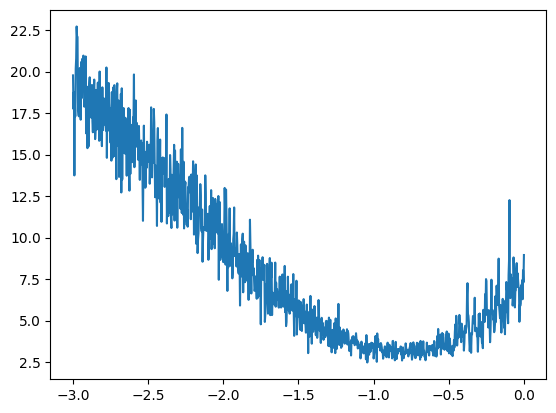

In [54]:
plt.plot(lr_i,loss_i)

* A learning rate around  0.1 is usually a good setting. In our initial setup, 0.1 was a fairly effective learning rate. This is roughly how you would determine it.

In [55]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [56]:

for i in range (1000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,X.shape[0], (32,))
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
 

19.620695114135742
15.627504348754883
16.573537826538086
12.964639663696289
12.302210807800293
14.54995059967041
14.072466850280762
12.986271858215332
10.607095718383789
9.10180950164795
11.722000122070312
12.098798751831055
11.248435974121094
8.065683364868164
9.918655395507812
11.002674102783203
9.269157409667969
9.84937858581543
5.157937526702881
8.827350616455078
8.435450553894043
10.140913009643555
9.635847091674805
8.14731502532959
8.61345100402832
8.357810020446777
8.282927513122559
7.193181037902832
7.128816604614258
7.089868545532227
3.8484537601470947
7.65841007232666
8.38573932647705
8.330255508422852
6.758485317230225
7.179047107696533
6.2763519287109375
6.9198126792907715
8.01282787322998
7.595619201660156
6.674135208129883
5.236945152282715
4.584673881530762
4.073505878448486
6.637161731719971
7.516841888427734
6.146109580993652
5.12791633605957
5.3715057373046875
4.087508678436279
4.501386642456055
6.363686561584473
4.349264144897461
5.665709018707275
5.010854244232178
4

* You first find a decent learning rate using the approach in the code above. Then, you start with that learning rate and train for a while. Toward the end, you can apply learning rate decay, reducing the learning rate by a factor of 10 and taking a few more steps. This helps in getting a well-trained network.


* As you add more neurons and parameters, the neural network's capacity to overfit the training set increases. This means the loss on the training set can become very low, even zero, indicating that the model is merely memorizing the training data. Consequently, when you sample from the model, it will reproduce the training data exactly, without generating any new data. Moreover, the loss on a separate evaluation set may be very high, revealing that the model does not generalize well. To address this, it is standard practice to split your dataset into three parts: the training set, the development (validation) set, and the test set.
* Eighty percent of your dataset is used for the training set to optimize the model's parameters through gradient descent. Ten percent is used for the development (or validation) split to tune the hyperparameters, such as the hidden layer size, embedding size, and regularization strength. You can try different settings and see which works best on the validation split. The training split trains the parameters, while the validation split helps tune the hyperparameters. The test split, the remaining ten percent, evaluates the model's performance at the end. You should only evaluate the loss on the test set sparingly, as frequent evaluation can lead to overfitting. Let's split our training data into train, dev, and test sets, then train on the train set and evaluate on the test set very sparingly.

In [57]:
# training split, valid siplit and test split
# %80, %10, %10
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?

  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtrain, Ytrain = build_dataset(words[:n1])
Xvalid, Yvalid = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [58]:
print(f'train samples: {Xtrain.shape[0]}')
print(f'train samples: {Xvalid.shape[0]}')
print(f'train samples: {Xtest.shape[0]}')

train samples: 182625
train samples: 22655
train samples: 22866


In [59]:
Xtrain.shape, Ytrain.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [60]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,100), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((100), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

3481


In [61]:
lre = torch.linspace(-3,0, 1000)
lrs = 10 ** lre


In [62]:
lr_i = []
loss_i = []
for i in range (30000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,Xtrain.shape[0], (32,))
    emb = C[Xtrain[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytrain[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # # track stats
    # lr_i.append(lre[i]) 
    # loss_i.append(loss.item())

In [63]:


print(loss.item())

2.3324618339538574


In [64]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.4352, grad_fn=<NllLossBackward0>)

In [65]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.4294, grad_fn=<NllLossBackward0>)

* We see that the training and dev losses are about equal, indicating that we're not overfitting. This model isn't powerful enough to purely memorize the data, and we are actually underfitting because the training and dev/test losses are roughly equal. This usually means our network is too small. To improve performance, we should scale up the size of the neural net. Let's increase the size of the neural net to address this.
* The easiest way to scale up is to increase the number of neurons in the hidden layer. Currently, it has 100 neurons, so let's increase it to 300. This means we'll also have 300 biases, and 300 inputs into the final layer. After initializing our neural net with these changes, we'll have ten thousand parameters instead of three thousand.

In [66]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)        # 27 characters, has2 dimensions each
W1 = torch.randn((6,300), generator=g)      # 3 characters, each with 2 embedding values, are used as inputs to 100 neurons.
b1 = torch.randn((300), generator=g)        # 100 biases added to the 100 neuron outputs
W2 = torch.randn((300,27), generator=g)     # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

10281


In [67]:
lr_i = []
loss_i = []
stepi = []
for i in range (70000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,Xtrain.shape[0], (32,))
    emb = C[Xtrain[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 +b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytrain[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr = 0.05
    for p in parameters:
        p.data += -lr * p.grad

    # # track stats
    stepi.append(i) 
    loss_i.append(loss.item())

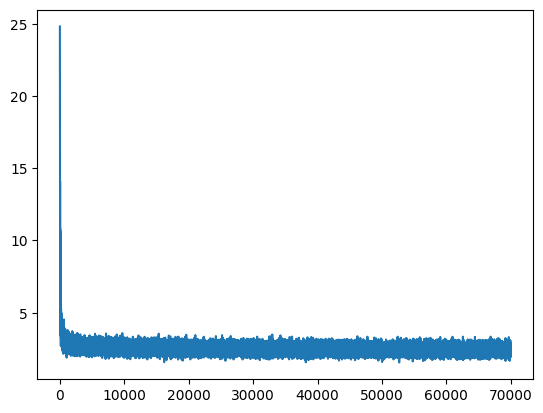

In [68]:
plt.plot(stepi,loss_i)

In [69]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.4008, grad_fn=<NllLossBackward0>)

In [70]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.4039, grad_fn=<NllLossBackward0>)

In [71]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.4008, grad_fn=<NllLossBackward0>)

In [72]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.4039, grad_fn=<NllLossBackward0>)

* These results are better than the results of the small size model. The reason why we increased the number of epochs is that the model needs more epochs as the number of parameters increases.
 * We can try different things to reduce the loss. one of them is embedding size increase

In [73]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,10), generator=g)        # 27 characters, has 10 dimensions each
W1 = torch.randn((30,200), generator=g)      # 3 characters, each with 10 embedding values, are used as inputs to 200 neurons.
b1 = torch.randn((200), generator=g)        # 200 biases added to the 200 neuron outputs
W2 = torch.randn((200,27), generator=g)     # 200 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g)         # 27 biases added to the 27 output neurons
parameters = [C, W1, b1, W2, b2] 

print(sum(p.nelement() for p in parameters))  # number of parameters

for p in parameters:
    p.requires_grad = True

11897


In [74]:
lr_i = []
loss_i = []
stepi = []
for i in range (100000):
    #forward pass
    
    # minibatch construct
    ix = torch.randint(0,Xtrain.shape[0], (32,))
    emb = C[Xtrain[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,30) @ W1 +b1) # its 30 because 3 characters, each with 10 embedding values 3*10
    logits = h @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytrain[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # # track stats
    stepi.append(i) 
    loss_i.append(loss.log10().item()) # it will looking good on plot

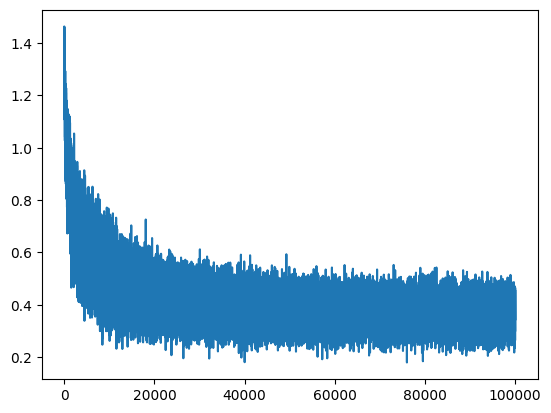

In [75]:
plt.plot(stepi,loss_i)

* its looking thick because of bath size we can decrease it

In [76]:
# loss on train set
emb = C[Xtrain]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.3282, grad_fn=<NllLossBackward0>)

In [77]:
# loss on valid set
emb = C[Xvalid]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yvalid)
loss

tensor(2.3359, grad_fn=<NllLossBackward0>)

* the clean code in above

In [78]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtrain.shape[0], (32,))
  
  # forward pass
  emb = C[Xtrain[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytrain[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  loss_i.append(loss.log10().item())

#print(loss.item())

In [79]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
aal.
harlin.
mili.
taty.
skanden.
jazhuel.
deliah.
jaree.
corrinittcheigh.
kaleigh.
ham.
joce.
quintis.
lilea.
jadiquinterri.
jaryxix.
kael.
ivraylen.
edi.
